<a href="https://colab.research.google.com/github/IA-PARA-DEVS-GRUPO-X/IA_PARA_DEVS_FASE1/blob/Hasanessaad-patch-1/AvaliacaoModelosML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## O PROBLEMA

O problema abordado neste trabalho consiste na identificação de pacientes mulheres com diabetes a partir de dados clínicos estruturados. Em ambientes hospitalares, o grande volume de pacientes e exames torna o processo de triagem mais lento e sujeito a erros.

Nesse contexto, a utilização de técnicas de Machine Learning pode auxiliar na análise inicial dos dados, permitindo identificar padrões que indicam a presença da doença. O desafio está em desenvolver um modelo capaz de realizar essa classificação de forma eficiente, reduzindo principalmente os casos de falsos negativos, que representam pacientes doentes não identificados.

## O OBJETIVO

O objetivo principal deste projeto é desenvolver um modelo de Machine Learning capaz de classificar pacientes em duas categorias: com diabetes e sem diabetes, com base em variáveis clínicas como glicose, índice de massa corporal e idade.

Além disso, busca-se avaliar diferentes algoritmos de classificação, comparar seus desempenhos e selecionar o modelo mais adequado.

O sistema proposto tem como finalidade atuar como ferramenta de apoio à decisão médica, contribuindo para a triagem inicial de pacientes e auxiliando profissionais de saúde na identificação precoce da doença.


In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, recall_score, f1_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.svm import LinearSVC
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

In [2]:
#Carregamento do dataset
import numpy as np
import scipy as sci
import pandas as pd

downloadFile = "https://drive.usercontent.google.com/download?id=1alYqPjQctUkym6krbm1Z9UbK1nxtrMTM&export=download&authuser=0&confirm=t&uuid=0d6d19ef-5e29-431a-b052-1e7188dacaae&at=ALBwUgnOwKH5Vf-A6z5xfdmv9Bmz:1776714804619"

df = pd.read_csv(downloadFile)
print(pd.DataFrame(df))
print(df.info())


     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50        1  
1                  

Exploração e Pré-processamento de dados.

Usaremos a função .head() do pandas para avaliar os primeiros registros do data frame.

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Para avaliar o objeto instanciado do data frame, usaremos a função  .info() do pandas.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.describe(include="all").T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


# Explicação de cada coluna

| Estatística | Significado                   | Explicação                                                     |
| ----------- | ----------------------------- | -------------------------------------------------------------- |
| **count**   | Contagem de valores não nulos | Mostra quantos valores válidos existem na coluna.              |
| **mean**    | Média                         | Soma dos valores dividida pela contagem.                       |
| **std**     | Desvio padrão                 | Mede a dispersão: quanto os valores variam em relação à média. |
| **min**     | Valor mínimo                  | O menor valor da coluna.                                       |
| **25%**     | Primeiro quartil (Q1)         | 25% dos valores estão abaixo desse número.                     |
| **50%**     | Mediana (Q2)                  | 50% dos valores estão abaixo desse número.                     |
| **75%**     | Terceiro quartil (Q3)         | 75% dos valores estão abaixo desse número.                     |
| **max**     | Valor máximo                  | O maior valor da coluna.                                       |


Observamos que alguns dados estão zerados em algumas colunas. Após análise, identificamos como dados suspeitos, portanto, trataremos esses dados como NaN indicando os dados como ausentes.

Foram aplicadas estratégias de pré-processamento para garantir a qualidade dos dados antes da modelagem.

Inicialmente, valores iguais a zero em variáveis como glicose, pressão arterial, espessura da pele, insulina e BMI foram considerados inconsistentes do ponto de vista médico e substituídos por valores ausentes (NaN).


In [6]:
cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df[cols] = df[cols].replace(0, np.nan)

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   763 non-null    float64
 2   BloodPressure             733 non-null    float64
 3   SkinThickness             541 non-null    float64
 4   Insulin                   394 non-null    float64
 5   BMI                       757 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


Agora vamos ver novamente como ficaram os dados após o tratamento.

In [7]:
df.describe(include="all").T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,763.0,121.686763,30.535641,44.000,99.00000,117.0000,141.00000,199.00
BloodPressure,733.0,72.405184,12.382158,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,541.0,29.153420,10.476982,7.000,22.00000,29.0000,36.00000,99.00
Insulin,394.0,155.548223,118.775855,14.000,76.25000,125.0000,190.00000,846.00
BMI,757.0,32.457464,6.924988,18.200,27.50000,32.3000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


Agora vamos gerar alguns gráficos para melhor avaliar os dados.

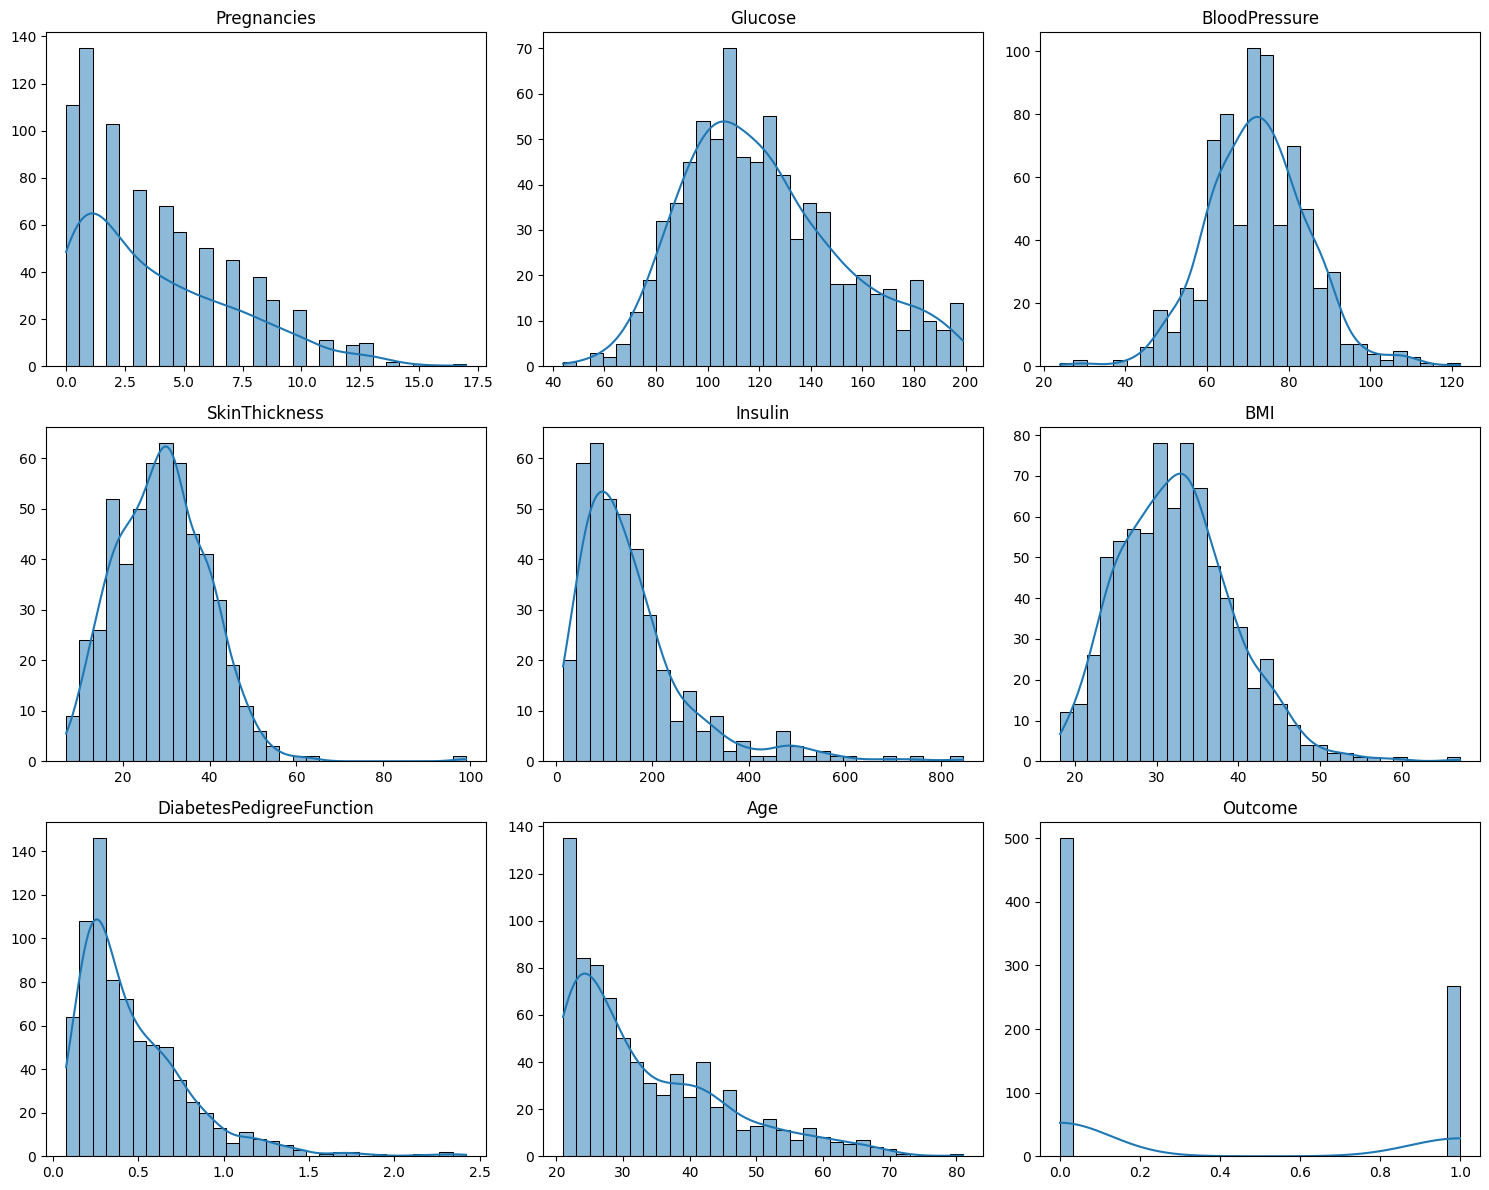

In [8]:
# Gráficos de frequencia em colunas
colunas_numericas = df.select_dtypes(include=['float64', 'int64']).columns

n_cols = 3  # quantidade de colunas
n_rows = (len(colunas_numericas) + n_cols - 1) // n_cols  # total de linhas

# cria a figura para receber gráficos
plt.figure(figsize=(15, 4 * n_rows))

# Laço para criar um subplot para cada variável
for i, coluna in enumerate(colunas_numericas, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[coluna], kde=True, bins=30)
    plt.title(f'{coluna}', fontsize=12)
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()

In [9]:
# Contagens de Outcome (Diabéticos/Não-Diabéticos)
counts = df['Outcome'].value_counts().sort_index()
total = counts.sum()
proportions = counts / total
print(proportions)

Outcome
0    0.651042
1    0.348958
Name: count, dtype: float64


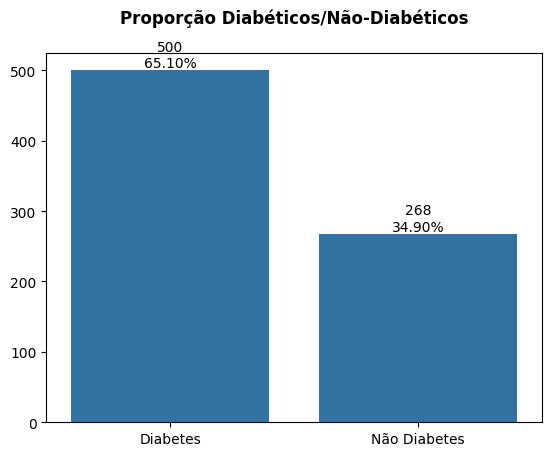

In [10]:
# Gráfico da proporção de Diabéticos/Não-Diabéticos
ax = sns.barplot(x=['Diabetes','Não Diabetes'],y=counts.values)
ax.set_title("Proporção Diabéticos/Não-Diabéticos\n", fontsize=12, weight='bold')

for i, (count, porcentagem) in enumerate(zip (counts, proportions * 100)):
  ax.text( i, count, f'{count:,}\n{porcentagem:.2f}%', ha= 'center', va= 'bottom')
plt.show()

<Axes: >

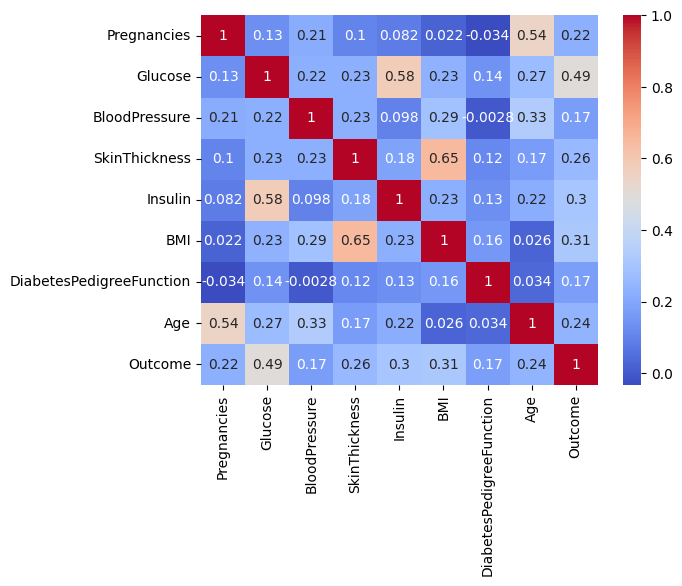

In [11]:
# Correlação de todas colunas
correlacao = df.corr()

sns.heatmap(correlacao, annot=True, cmap="coolwarm")

Em seguida, foi aplicada a técnica de imputação utilizando a mediana, garantindo que valores faltantes fossem tratados de forma robusta, sem distorcer a distribuição dos dados.

In [12]:
imputer = SimpleImputer(strategy="median")

df[cols] = imputer.fit_transform(df[cols])

df.describe(include="all")

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Além disso, foi utilizado um pipeline de pré-processamento contendo imputação e padronização dos dados (StandardScaler), assegurando que todas as variáveis estivessem na mesma escala e evitando problemas em modelos sensíveis à magnitude dos dados.

Essa abordagem garante consistência no processamento e evita problemas como data leakage.


                Modelo  Accuracy  Recall  F1-score     AUC
0        Random Forest    0.7792  0.6111    0.6600  0.8179
1                  KNN    0.7532  0.6111    0.6346  0.7886
2                  SVM    0.7403  0.5556    0.6000  0.7964
3  Logistic Regression    0.7078  0.5000    0.5455  0.8130


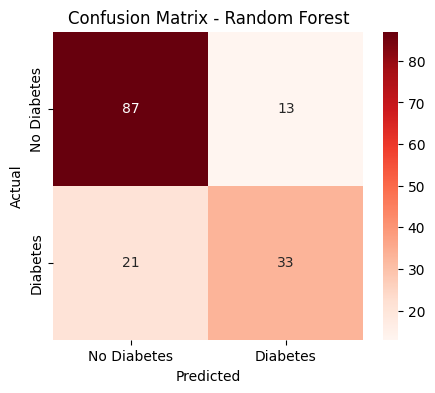

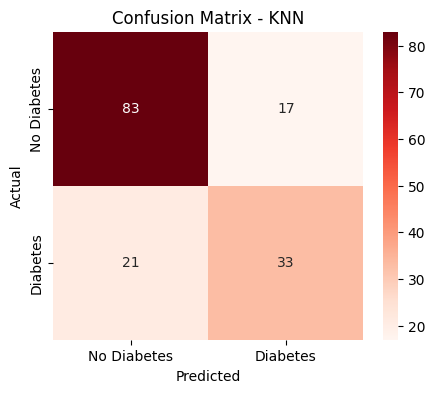

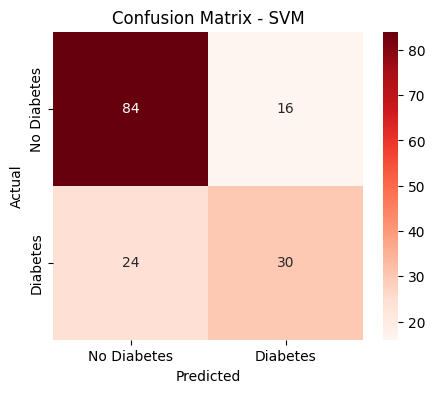

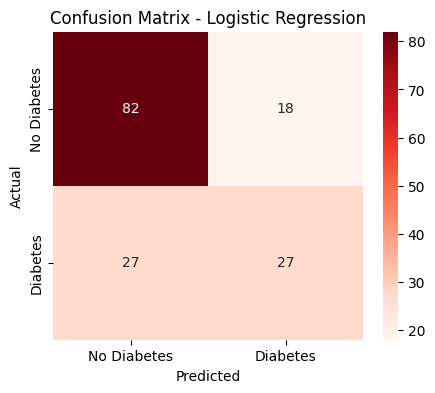


Best model: Random Forest


In [13]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# Split ONCE
# 20% test, 80% training
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Define models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(probability=True),
    "Logistic Regression": LogisticRegression(max_iter=1000)
}

conf_matrices = {}
results = []

# Training and validation
for name, model in models.items():

    pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    # Saving matrix
    conf_matrices[name] = confusion_matrix(y_test, y_pred)

    results.append({
        "Modelo": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results).round(4)

# Order by Recall
results_df = results_df.sort_values(by="Recall", ascending=False)

print(results_df)

for name, cm in conf_matrices.items():
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
                xticklabels=['No Diabetes', 'Diabetes'],
                yticklabels=['No Diabetes', 'Diabetes'])

    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


# Best model considering recall
best_model = results_df.iloc[0]["Modelo"]

print(f"\nBest model: {best_model}")


# **Avaliação do modelo**

## Escolha da métrica
Optou-se por escolher o **recall** como principal métrica de validação, uma vez que os quatro modelos apresentam níveis de acurácia relativamente semelhantes. Por se tratar de um problema envolvendo dados sensíveis relacionados ao diagnóstico de diabetes, é fundamental priorizar a minimização de **falsos negativos**, ou seja, evitar classificar como saudáveis pacientes que realmente possuem a doença. Esse tipo de erro pode atrasar o diagnóstico e comprometer o tratamento adequado. Nesse contexto, o recall se destaca por medir diretamente a capacidade do modelo em identificar corretamente os casos positivos (pacientes com diabetes), sendo, portanto, a métrica mais adequada a ser utilizada.

Entre os modelos avaliados, tanto o KNN quanto o Random Forest obtiveram a maior nivel de revocação (0,6111). No entanto, o Random Forest superou o KNN em termos de AUC (0,8179) e acurácia (0,7792), indicando um melhor desempenho discriminativo geral.

Portanto, o Random Forest foi selecionado como o modelo de melhor desempenho, pois oferece um bom equilíbrio entre a detecção de pacientes diabéticos e a manutenção da acurácia preditiva geral.

## Escolha do modelo KNN

O modelo KNN apresentou um bom desempenho, alcançando um valor de recall de 0,6111, o que indica uma capacidade razoável de identificar pacientes com diabetes. Além disso, apresentou uma acurácia de 75,32% e um AUC de 0,7886.

Apesar de obter o mesmo nível de recall que o modelo Random Forest, o KNN apresentou desempenho inferior em termos de AUC e acurácia, indicando menor capacidade de generalização e discriminação entre as classes. Ainda assim, o modelo foi útil como referência e base de comparação por sua simplicidade e facilidade de implementação.

## Escolha do modelo SVM

O modelo SVM apresentou desempenho intermediário, com um recall de 0,5556, acurácia de 74,03% e AUC de 0,7963. Embora tenha demonstrado uma boa capacidade de separação entre as classes, seu desempenho foi inferior ao dos modelos KNN e Random Forest na identificação de casos positivos.

Além disso, o SVM apresenta limitações em termos de interpretabilidade, o que dificulta sua aplicação em contextos médicos, onde a transparência das decisões é essencial. Dessa forma, o modelo foi considerado como uma alternativa válida, porém não ideal para o problema proposto.

## Escolha do modelo Regressão Logística

A Regressão Logística apresentou o menor desempenho entre os modelos avaliados, com recall de 0,5000, acurácia de 70,78% e AUC de 0,8130. Embora tenha apresentado um AUC competitivo, sua capacidade de identificar corretamente pacientes com diabetes foi inferior, resultando em maior número de falsos negativos.

Por outro lado, a Regressão Logística se destaca pela sua interpretabilidade, sendo amplamente utilizada em aplicações médicas. No entanto, para este problema específico, sua performance em termos de recall foi insuficiente quando comparada aos demais modelos.

## Escolha do modelo Random Forest

O modelo Random Forest apresentou o melhor desempenho geral entre os modelos avaliados. Embora tenha alcançado o mesmo valor de recall que o KNN (0,6111), destacou-se por apresentar maior acurácia (77,92%) e maior AUC (0,8179), indicando melhor capacidade de discriminação entre pacientes com e sem diabetes.

Essa combinação de métricas demonstra que o Random Forest consegue equilibrar de forma eficiente a identificação de casos positivos com a performance geral do modelo. Além disso, sua capacidade de capturar relações não lineares entre as variáveis contribui para um desempenho mais robusto.

Dessa forma, o Random Forest foi selecionado como o modelo mais adequado para o problema proposto.

In [14]:
# Get trained Random Forest pipeline
rf_pipeline = None

for name, model in models.items():
    if name == "Random Forest":
        rf_pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", model)
        ])
        rf_pipeline.fit(X_train, y_train)

# Extract model
rf_model = rf_pipeline.named_steps["model"]

feature_names = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"
]

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance_df)


                    Feature  Importance
1                   Glucose    0.274086
5                       BMI    0.161903
6  DiabetesPedigreeFunction    0.125020
7                       Age    0.112985
4                   Insulin    0.091224
2             BloodPressure    0.083518
0               Pregnancies    0.080795
3             SkinThickness    0.070468


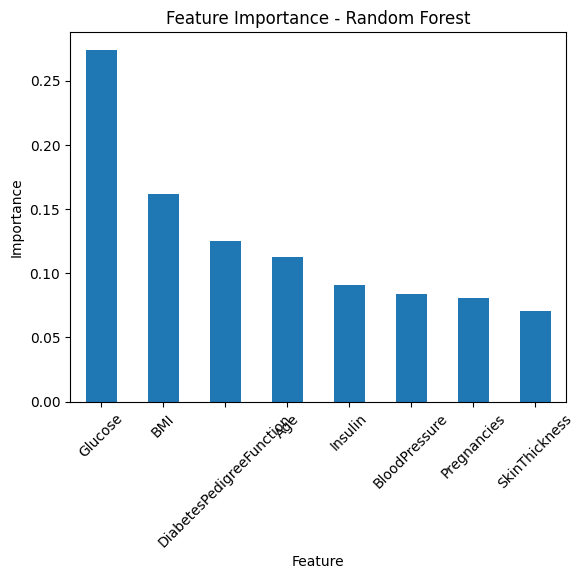

In [15]:
import matplotlib.pyplot as plt

importance_df.plot(kind="bar", x="Feature", y="Importance", legend=False)
plt.title("Feature Importance - Random Forest")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

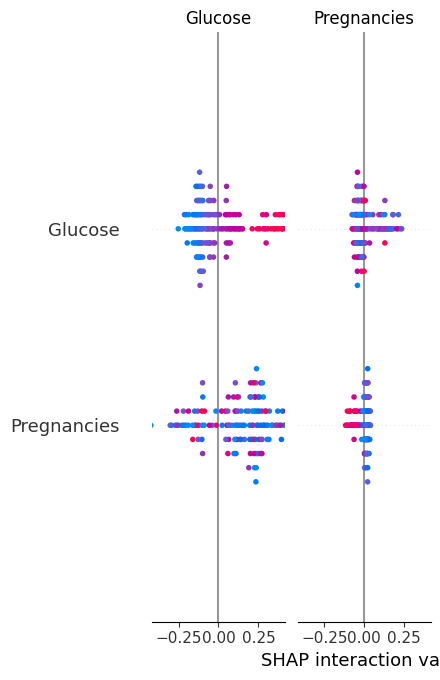

In [16]:
import shap

feature_names = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"
]

# Apply preprocessing
X_test_transformed = rf_pipeline.named_steps["scaler"].transform(
    rf_pipeline.named_steps["imputer"].transform(X_test)
)

# Convert for visualization
X_test_df = pd.DataFrame(X_test, columns=feature_names)

# SHAP
explainer = shap.Explainer(rf_model)
shap_values = explainer(X_test_transformed)

# Plot
shap.summary_plot(shap_values.values, X_test_df)

## Interpretação dos Resultados

A interpretação dos resultados foi realizada utilizando duas abordagens principais: análise de importância das variáveis (feature importance) e a técnica SHAP (SHapley Additive Explanations).

A análise de feature importance, baseada no modelo Random Forest, revelou que a variável mais relevante para a predição da diabetes é o nível de glicose, seguida por outras variáveis como índice de massa corporal (BMI), idade e histórico familiar (Diabetes Pedigree Function). Esses resultados são coerentes com o conhecimento médico, uma vez que níveis elevados de glicose e obesidade são fatores diretamente associados ao desenvolvimento da diabetes.

A técnica SHAP foi utilizada para aprofundar a interpretação do modelo, permitindo entender como cada variável influencia individualmente as predições. Observou-se que valores elevados de glicose e BMI aumentam significativamente a probabilidade do paciente ser classificado como diabético, enquanto valores mais baixos dessas variáveis contribuem para a classificação como não diabético.

Além disso, variáveis como idade e número de gestações também apresentaram influência no modelo, indicando que fatores relacionados ao histórico do paciente contribuem para o risco da doença.

Essas análises demonstram que o modelo não apenas apresenta bom desempenho, mas também toma decisões baseadas em variáveis clinicamente relevantes. A utilização de técnicas interpretáveis como SHAP é fundamental em aplicações na área da saúde, pois permite maior transparência e confiança no uso do modelo como ferramenta de apoio à decisão médica.



## DISCUSSÃO

Os resultados obtidos demonstram que o modelo Random Forest apresentou o melhor desempenho geral, com bom equilíbrio entre acurácia, recall e AUC. No entanto, apesar desses resultados positivos, é necessário analisar criticamente suas limitações, especialmente considerando o contexto médico da aplicação.

A métrica recall foi priorizada neste estudo por sua importância na detecção de pacientes com diabetes. Mesmo assim, o valor obtido (~0,61) indica que uma parcela significativa dos casos positivos ainda não é identificada pelo modelo. Em um cenário real, esses falsos negativos representam pacientes que possuem a doença, mas não seriam detectados pelo sistema, o que pode atrasar o diagnóstico e o início do tratamento.

Além disso, o dataset utilizado apresenta limitações, como tamanho reduzido e possível falta de representatividade da população geral. Fatores importantes para o diagnóstico da diabetes, como hábitos alimentares, nível de atividade física e histórico clínico mais detalhado, não estão presentes nos dados, o que restringe a capacidade preditiva do modelo.

Outro ponto relevante é que, embora o modelo Random Forest tenha apresentado bom desempenho, ele ainda possui limitações em termos de interpretabilidade quando comparado a modelos mais simples, como a Regressão Logística. Por esse motivo, a utilização de técnicas como SHAP foi essencial para compreender melhor como o modelo toma decisões.

Dessa forma, o modelo desenvolvido pode ser utilizado na prática como uma ferramenta de apoio à decisão médica, auxiliando na triagem inicial de pacientes e na identificação de casos com maior risco de diabetes. No entanto, ele não deve, em hipótese alguma, ser utilizado como substituto do diagnóstico clínico.

O papel do médico permanece fundamental, sendo responsável por interpretar os resultados, considerar o contexto clínico do paciente e validar qualquer decisão tomada com base no sistema. O modelo deve ser visto como um recurso complementar, que contribui para aumentar a eficiência do processo de triagem, mas sempre sob supervisão profissional.

Portanto, embora os resultados sejam promissores, melhorias adicionais são necessárias antes da aplicação em ambientes reais, como o uso de datasets maiores, validação externa e otimização dos modelos para aumentar o recall e reduzir a taxa de falsos negativos.
